In [2]:
import os
import socket

# Detect which machine we're running on
hostname = socket.gethostname()

if "daic" in hostname or "tudelft" in hostname or "hpc" in hostname:
    # Running on DAIC
    os.environ["HF_HOME"] = "/tudelft.net/staff-umbrella/lsuryana/huggingface"
    MODEL_PATH = "Qwen/Qwen2-VL-7B-Instruct"
    DATA_PATH = "/tudelft.net/staff-umbrella/lsuryana/rq2-posthoc-driving/data/nuscenes"
else:
    # Running on WSL/local
    os.environ["HF_HOME"] = os.path.expanduser("~/.cache/huggingface")
    MODEL_PATH = "Qwen/Qwen2-VL-7B-Instruct"
    DATA_PATH = os.path.expanduser("~/rq2-posthoc-driving/data/nuscenes")

print(f"Running on: {hostname}")
print(f"HF_HOME: {os.environ['HF_HOME']}")
print(f"MODEL_PATH: {MODEL_PATH}")
print(f"DATA_PATH: {DATA_PATH}")

Running on: login1.hpc.tudelft.nl
HF_HOME: /tudelft.net/staff-umbrella/lsuryana/huggingface
MODEL_PATH: Qwen/Qwen2-VL-7B-Instruct
DATA_PATH: /tudelft.net/staff-umbrella/lsuryana/rq2-posthoc-driving/data/nuscenes


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1: Load model
# ─────────────────────────────────────────────────────────────────────────────
import json, os, re, torch, time, gc, math
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# MODEL_PATH = "/home/lsuryana/.cache/huggingface/hub/Qwen2-VL-7B-Instruct"
print("Loading model...")
model = Qwen2VLForConditionalGeneration.from_pretrained(
    MODEL_PATH, torch_dtype="auto", device_map="cuda")
processor = AutoProcessor.from_pretrained(MODEL_PATH)
print(f"Model loaded. VRAM: {round(torch.cuda.memory_allocated()/1e9,2)} GB")

Loading model...


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

model-00001-of-00005.safetensors:   0%|          | 0.00/3.90G [00:00<?, ?B/s]

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2: Load data, prompts, and helper functions
# ─────────────────────────────────────────────────────────────────────────────
import json, os, re, torch, time, gc, math
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, HTML
from qwen_vl_utils import process_vision_info

from scripts.labels import continuous_to_drivelm_label

# Load data
with open('results/preprocessed.json') as f:
    data = json.load(f)

# Load prompts (5 steps: perception -> comprehension -> projection -> planning -> behavior)
p1 = open('prompts/step1_perception.txt').read()
p2 = open('prompts/step2_comprehension.txt').read()
p3 = open('prompts/step3_projection.txt').read()
p4 = open('prompts/step4_planning.txt').read()
p5 = open('prompts/step5_behavior.txt').read()

IMAGE_SIZE = (640, 360)

# Image helpers

def resize_image(path):
    tmp = path.replace('.jpg', '_r.jpg')
    if not os.path.exists(tmp):
        img = Image.open(path).convert('RGB').resize(IMAGE_SIZE, Image.LANCZOS)
        img.save(tmp, quality=85)
    return tmp

def get_image_sequence(s, condition):
    fd     = s['frame_dir']
    n_past = s.get('n_past', 0)
    past_frames = []
    if n_past >= 3:
        past_frames = [f"{fd}/tm3.jpg", f"{fd}/tm2.jpg", f"{fd}/tm1.jpg"]
    elif n_past == 2:
        past_frames = [f"{fd}/tm2.jpg", f"{fd}/tm1.jpg"]
    elif n_past == 1:
        past_frames = [f"{fd}/tm1.jpg"]
    current = [f"{fd}/t0.jpg"]
    future  = [f"{fd}/t1.jpg", f"{fd}/t2.jpg", f"{fd}/t3.jpg"] \
              if condition == 'posthoc' else []
    return past_frames + current + future

def build_image_description(s, condition):
    n_past = s.get('n_past', 0)
    lines  = []
    if n_past == 3:
        lines += [
            "- Image 1: t-3 (1.5 seconds before decision point)",
            "- Image 2: t-2 (1.0 second before decision point)",
            "- Image 3: t-1 (0.5 seconds before decision point)",
            "- Image 4: t0  (current frame -- DECISION POINT)",
        ]
        if condition == 'posthoc':
            lines += [
                "- Image 5: t+1 (0.5 seconds after decision point)",
                "- Image 6: t+2 (1.0 second after decision point)",
                "- Image 7: t+3 (1.5 seconds after decision point)",
            ]
    elif n_past == 2:
        lines += [
            "- Image 1: t-2 (1.0 second before decision point)",
            "- Image 2: t-1 (0.5 seconds before decision point)",
            "- Image 3: t0  (current frame -- DECISION POINT)",
        ]
        if condition == 'posthoc':
            lines += [
                "- Image 4: t+1 (0.5 seconds after decision point)",
                "- Image 5: t+2 (1.0 second after decision point)",
                "- Image 6: t+3 (1.5 seconds after decision point)",
            ]
    return "\n".join(lines)

# Inference helpers

def run_inference(messages, max_tokens=128):
    torch.cuda.empty_cache()
    gc.collect()
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True)
    has_images = any(
        isinstance(item, dict) and item.get('type') == 'image'
        for msg in messages
        for item in msg.get('content', [])
    )
    if has_images:
        image_inputs, _ = process_vision_info(messages)
        inputs = processor(
            text=[text], images=image_inputs, return_tensors="pt").to("cuda")
    else:
        inputs = processor(text=[text], return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = model.generate(
            **inputs, max_new_tokens=max_tokens,
            temperature=0.0, do_sample=False)
    trimmed = out[:, inputs['input_ids'].shape[1]:]
    result  = processor.decode(trimmed[0], skip_special_tokens=True)
    del inputs, out, trimmed
    torch.cuda.empty_cache()
    return result

def parse_step(raw, step):
    """Extract a tagged field from model output.

    SA pipeline tags:
      perception_summary    -- SA Level 1 full Q&A summary
      comprehension_summary -- SA Level 2 full Q&A summary
      prediction_summary    -- SA Level 3 full Q&A summary
      planning              -- planning recommendation
      speed / angle / acceleration / yaw_rate / reasoning -- behavior outputs
    """
    patterns = {
    'perception_summary':    r'PERCEPTION_SUMMARY:\s*(.*?)$',
    'comprehension_summary': r'COMPREHENSION_SUMMARY:\s*(.*?)$',
    'prediction_summary':    r'PREDICTION_SUMMARY:\s*(.*?)$',
    'perception':            r'PERCEPTION:\s*(.*?)$',
    'prediction':            r'PREDICTION:\s*(.*?)$',
    'planning':              r'PLANNING:\s*(.*?)$',
    'direction':             r'DIRECTION:\s*(.+?)(?:\n|$)',
    'speed':                 r'SPEED:\s*(.+?)(?:\n|$)',
    'reasoning':             r'REASONING:\s*(.*?)$',
    }
    match = re.search(patterns[step], raw, re.DOTALL | re.MULTILINE)
    return match.group(1).strip() if match else ''

# ── GT label access ───────────────────────────────────────────────────────────
# Labels are pre-computed in gt_continuous by scripts/02b_add_gt_continuous.py.
# Use the derived field as the canonical source so categorical and continuous
# evaluation both flow from the same continuous physics computation.

def get_gt_label(sample):
    """Return DriveLM-style label for a sample, preferring the derived one."""
    if 'gt_continuous' in sample and 'drivelm_label' in sample['gt_continuous']:
        return sample['gt_continuous']['drivelm_label']
    return sample.get('gt_label', '')

print(f"Loaded {len(data)} samples.")
print("Helper functions ready.")
print("\nGT label distribution:")
from collections import Counter
gt_dist = Counter(get_gt_label(s) for s in data)
for k, v in sorted(gt_dist.items(), key=lambda x: -x[1]):
    print(f"  {v:2d}x  {k}")

def get_gt_continuous(s):
    return s.get('gt_continuous') or {}

def get_prev_continuous(s):
    return s.get('prev_continuous') or {}

def safe_float(v, default=0.0):
    try:
        return float(v)
    except (ValueError, TypeError):
        return default

def compute_mae(predicted, gt_dict, key):
    gt_val = gt_dict.get(key)
    if gt_val is None or predicted is None:
        return None
    return abs(predicted - gt_val)

def get_past_behavior_label(past_traj, n_past):
    """
    Derive a single speed and direction label from the past trajectory
    window, using the same thresholds as GT labelling in labels.py.
    Computes total displacement from earliest past point to t0 (origin).
    """
    if n_past == 0 or not past_traj:
        return continuous_to_drivelm_label(0.0, 0.0)

    earliest      = past_traj[0]
    dx            = 0.0 - earliest['x']
    dy            = 0.0 - earliest['y']
    dt            = n_past * 0.5
    dist          = math.sqrt(dx**2 + dy**2)
    avg_speed_mps = dist / dt
    angle_deg     = math.degrees(math.atan2(dy, dx)) if dist > 0.01 else 0.0

    return continuous_to_drivelm_label(avg_speed_mps, angle_deg)

print("Past behavior label sanity check:")
for idx in [0, 7]:
    s      = data[idx]
    pt     = s.get('past_trajectory', [])
    n_past = s.get('n_past', 0)
    gt     = get_gt_continuous(s)

    # correct
    dir_lbl, spd_lbl = get_past_behavior_label(pt, n_past)
    gt_dir, gt_spd   = continuous_to_drivelm_label(
        gt.get('avg_speed_mps', 0),
        gt.get('angle_overall_deg', 0)
    )
    print(f"\n  Sample {idx}:")
    print(f"    Past label: {spd_lbl} | {dir_lbl}")
    print(f"    GT label:   {gt_spd}  | {gt_dir}")

Loaded 24 samples.
Helper functions ready.

GT label distribution:
   7x  The ego vehicle is going straight. The ego vehicle is not moving.
   5x  The ego vehicle is going straight. The ego vehicle is driving very fast.
   3x  The ego vehicle is going straight. The ego vehicle is driving with normal speed.
   3x  The ego vehicle is slightly steering to the right. The ego vehicle is driving slowly.
   1x  The ego vehicle is slightly steering to the right. The ego vehicle is driving fast.
   1x  The ego vehicle is going straight. The ego vehicle is driving slowly.
   1x  The ego vehicle is going straight. The ego vehicle is driving fast.
   1x  The ego vehicle is steering to the right. The ego vehicle is driving slowly.
   1x  The ego vehicle is slightly steering to the left. The ego vehicle is driving slowly.
   1x  The ego vehicle is slightly steering to the right. The ego vehicle is driving with normal speed.
Past behavior label sanity check:

  Sample 0:
    Past label: not moving | 

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2b: run_condition_v5
# SA-structured 5-step pipeline:
#   Step 1 -- SA Level 1: Perception     -> PERCEPTION_SUMMARY
#   Step 2 -- SA Level 2: Comprehension  -> COMPREHENSION_SUMMARY
#   Step 3 -- SA Level 3: Projection     -> PREDICTION_SUMMARY
#   Step 4 -- Planning                   -> PLANNING
#   Step 5 -- Behavior                   -> SPEED / ANGLE / ACCELERATION / YAW_RATE
# ─────────────────────────────────────────────────────────────────────────────

def build_context_header(s, condition):
    images    = get_image_sequence(s, condition)
    n_total   = len(images)
    n_past    = s.get('n_past', 0)
    traj      = s['trajectory']
    past_traj = s.get('past_trajectory', [])
    gt_cont   = get_gt_continuous(s)
    prev_cont = get_prev_continuous(s)
    img_desc  = build_image_description(s, condition)
    ego_goal  = s.get('ego_goal', 'continue driving safely along the current road')

    past_traj_text = ""
    if n_past >= 3:
        past_traj_text = (
            f"  t-1.5s: x={past_traj[0]['x']}, y={past_traj[0]['y']}\n"
            f"  t-1.0s: x={past_traj[1]['x']}, y={past_traj[1]['y']}\n"
            f"  t-0.5s: x={past_traj[2]['x']}, y={past_traj[2]['y']}\n"
        )
    elif n_past == 2:
        past_traj_text = (
            f"  t-1.0s: x={past_traj[0]['x']}, y={past_traj[0]['y']}\n"
            f"  t-0.5s: x={past_traj[1]['x']}, y={past_traj[1]['y']}\n"
        )
    
    if n_past >= 1:
        spd_lbl, dir_lbl = get_past_behavior_label(past_traj, n_past)
        past_traj_text += (
            f"Ego vehicle past behavior "
            f"(aggregated over past window):\n"
            f"  speed:     {spd_lbl}\n"
            f"  direction: {dir_lbl}\n"
        )

    if prev_cont:
        past_motion_text = (
            f"  avg speed:    {prev_cont.get('avg_speed_mps', 0)} m/s "
            f"({prev_cont.get('avg_speed_kph', 0)} km/h)\n"
            f"  acceleration: {prev_cont.get('acceleration_mps2', 0)} m/s2\n"
            f"  heading:      {prev_cont.get('angle_overall_deg', 0)} degrees\n"
            f"  yaw rate:     {prev_cont.get('yaw_rate_deg_s', 0)} deg/s\n"
        )
    else:
        past_motion_text = "  not available\n"

    header = (
        f"You have access to {n_total} images showing the driving scene:\n"
        f"{img_desc}\n\n"
        f"Ego vehicle goal: {ego_goal}\n\n"
        f"Ego vehicle past trajectory (x=forward meters, y=left meters, relative to t0):\n"
        f"{past_traj_text}"
        f"Ego vehicle past motion state:\n"
        f"{past_motion_text}"
    )

    if condition == 'posthoc':
        header += (
            f"\nEgo vehicle future trajectory (ground-truth):\n"
            f"  t+0.5s: x={traj[0]['x']}, y={traj[0]['y']}\n"
            f"  t+1.0s: x={traj[1]['x']}, y={traj[1]['y']}\n"
            f"  t+1.5s: x={traj[2]['x']}, y={traj[2]['y']}\n"
            f"Ego vehicle future motion state (ground-truth):\n"
            f"  avg speed:    {gt_cont.get('avg_speed_mps', 0)} m/s "
            f"({gt_cont.get('avg_speed_kph', 0)} km/h)\n"
            f"  heading:      {gt_cont.get('angle_overall_deg', 0)} degrees\n"
            f"  acceleration: {gt_cont.get('acceleration_mps2', 0)} m/s2\n"
            f"  yaw rate:     {gt_cont.get('yaw_rate_deg_s', 0)} deg/s\n"
        )

    return header


def run_condition_v5(s, condition):
    """
    5-step SA-structured inference pipeline.
    Step 1 -- SA Level 1: Perception      (images + trajectory) -> PERCEPTION_SUMMARY
    Step 2 -- SA Level 2: Comprehension   (PERCEPTION_SUMMARY)  -> COMPREHENSION_SUMMARY
    Step 3 -- SA Level 3: Projection      (COMPREHENSION_SUMMARY) -> PREDICTION_SUMMARY
    Step 4 -- Planning                    (PREDICTION_SUMMARY)  -> PLANNING
    Step 5 -- Behavior                    (full context)        -> SPEED/ANGLE/ACCEL/YAW
    """
    images  = get_image_sequence(s, condition)
    resized = [resize_image(img) for img in images]
    n_total = len(images)
    context_header = build_context_header(s, condition)

    def img_content():
        return [{"type": "image", "image": p} for p in resized]

    # Step 1: SA Level 1 -- Perception (WITH images)
    prompt1 = context_header + "\n" + p1
    msg1 = [{"role": "user", "content":
        img_content() + [{"type": "text", "text": prompt1}]}]
    raw1 = run_inference(msg1, max_tokens=1200)
    perc_summary = parse_step(raw1, 'perception_summary') or raw1.strip()

    # Step 2: SA Level 2 -- Comprehension (NO images)
    prompt2 = (
        context_header +
        f"\nPerception analysis:\n{raw1}\n\n"
        f"Perception summary: {perc_summary}\n\n"
    ) + p2
    msg2 = [{"role": "user", "content":
        [{"type": "text", "text": prompt2}]}]
    raw2 = run_inference(msg2, max_tokens=512)
    comp_summary = parse_step(raw2, 'comprehension_summary') or raw2.strip()

    # Step 3: SA Level 3 -- Projection (NO images)
    prompt3 = (
        context_header +
        f"\nComprehension summary: {comp_summary}\n\n"
    ) + p3
    msg3 = [{"role": "user", "content":
        [{"type": "text", "text": prompt3}]}]
    raw3 = run_inference(msg3, max_tokens=512)
    pred_summary = parse_step(raw3, 'prediction_summary') or raw3.strip()

    # Step 4: Planning (NO images)
    prompt4 = (
        context_header +
        f"\nPerception summary:    {perc_summary}\n"
        f"Comprehension summary: {comp_summary}\n"
        f"Prediction summary:    {pred_summary}\n\n"
    ) + p4
    msg4 = [{"role": "user", "content":
        [{"type": "text", "text": prompt4}]}]
    raw4 = run_inference(msg4, max_tokens=256)
    ans_plan = parse_step(raw4, 'planning') or raw4.strip()

# Step 5: Behavior (NO images) — categorical
    prompt5 = (
        context_header +
        f"\nPerception summary:    {perc_summary}\n"
        f"Comprehension summary: {comp_summary}\n"
        f"Prediction summary:    {pred_summary}\n"
        f"Planning:              {ans_plan}\n\n"
    ) + p5
    msg5 = [{"role": "user", "content":
        [{"type": "text", "text": prompt5}]}]
    raw5 = run_inference(msg5, max_tokens=128)

    direction = parse_step(raw5, 'direction')
    speed     = parse_step(raw5, 'speed')
    reasoning = parse_step(raw5, 'reasoning')

    gt = get_gt_continuous(s)
    gt_direction = gt.get('direction_label', '')
    gt_speed     = gt.get('speed_label', '')
    direction_correct = (direction == gt_direction)
    speed_correct     = (speed     == gt_speed)

    return {
        'perception_raw':        raw1,
        'perception_summary':    perc_summary,
        'comprehension_raw':     raw2,
        'comprehension_summary': comp_summary,
        'prediction_raw':        raw3,
        'prediction_summary':    pred_summary,
        'planning':              ans_plan,
        'direction':             direction,
        'speed':                 speed,
        'reasoning':             reasoning,
        'raw_step5':             raw5,
        'gt_direction':          gt_direction,
        'gt_speed':              gt_speed,
        'direction_correct':     direction_correct,
        'speed_correct':         speed_correct,
        'full_correct':          direction_correct and speed_correct,
        'n_images':              n_total,
    }

# Verify context headers
print("Context headers for sample 0:\n")
print("NON POST-HOC:")
print(build_context_header(data[0], 'non_posthoc'))
print("\nPOST-HOC:")
print(build_context_header(data[0], 'posthoc'))


Context headers for sample 0:

NON POST-HOC:
You have access to 4 images showing the driving scene:
- Image 1: t-3 (1.5 seconds before decision point)
- Image 2: t-2 (1.0 second before decision point)
- Image 3: t-1 (0.5 seconds before decision point)
- Image 4: t0  (current frame -- DECISION POINT)

Ego vehicle goal: continue driving safely along the current road

Ego vehicle past trajectory (x=forward meters, y=left meters, relative to t0):
  t-1.5s: x=0.0, y=0.0
  t-1.0s: x=0.0, y=0.0
  t-0.5s: x=0.0, y=0.0
Ego vehicle past behavior (aggregated over past window):
  speed:     going straight
  direction: not moving
Ego vehicle past motion state:
  avg speed:    0.0 m/s (0.0 km/h)
  acceleration: 0.0 m/s2
  heading:      0.0 degrees
  yaw rate:     0.0 deg/s


POST-HOC:
You have access to 7 images showing the driving scene:
- Image 1: t-3 (1.5 seconds before decision point)
- Image 2: t-2 (1.0 second before decision point)
- Image 3: t-1 (0.5 seconds before decision point)
- Image 4: 

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2c: Step-by-step validation — sample 7, non post-hoc
# Shows full prompt AND VLM answer for each of the 5 SA steps
# ─────────────────────────────────────────────────────────────────────────────

s         = data[0]
fd        = s['frame_dir']
n_past    = s.get('n_past', 0)
traj      = s['trajectory']
past_traj = s.get('past_trajectory', [])
gt_cont   = s.get('gt_continuous', {})
prev_cont = s.get('prev_continuous', {})

print(f"Sample: {s['sample_token'][:8]}")
print(f"GT: speed={gt_cont.get('avg_speed_kph')} km/h, "
      f"angle={gt_cont.get('angle_overall_deg')} degrees\n")

# Build image sequence (non post-hoc)
past_frames = []
if n_past >= 3:
    past_frames = [f"{fd}/tm3.jpg", f"{fd}/tm2.jpg", f"{fd}/tm1.jpg"]
elif n_past == 2:
    past_frames = [f"{fd}/tm2.jpg", f"{fd}/tm1.jpg"]
images  = past_frames + [f"{fd}/t0.jpg"]
resized = [resize_image(p) for p in images]

def img_content():
    return [{"type": "image", "image": p} for p in resized]

# Build context header (non post-hoc)
context_header = build_context_header(s, 'non_posthoc')

SEP  = "=" * 60
DASH = "-" * 60

def print_step(step_num, step_name, sa_level, prompt, raw):
    print(f"\n{SEP}")
    print(f"STEP {step_num} -- {step_name}  [{sa_level}]")
    print(f"{SEP}")
    print("PROMPT:")
    print(prompt)
    print(f"\n{DASH}")
    print("VLM ANSWER:")
    print(raw)

# ── STEP 1: SA Level 1 -- Perception (WITH images) ───────────────────────────
prompt1 = context_header + "\n" + p1
msg1    = [{"role": "user", "content":
    img_content() + [{"type": "text", "text": prompt1}]}]
raw1    = run_inference(msg1, max_tokens=768)
perc_summary = parse_step(raw1, 'perception_summary') or raw1.strip()
print_step(1, "PERCEPTION", "SA Level 1", prompt1, raw1)
print(f"\n  >> PERCEPTION_SUMMARY extracted ({len(perc_summary)} chars)")

# ── STEP 2: SA Level 2 -- Comprehension (NO images) ──────────────────────────
# Receives full raw Q&A from Step 1 + its summary, so comprehension
# can reference any detail from the perception chain of thought.
prompt2 = (
    context_header +
    f"\nPerception analysis:\n{raw1}\n\n"
    f"Perception summary: {perc_summary}\n\n"
) + p2
msg2  = [{"role": "user", "content":
    [{"type": "text", "text": prompt2}]}]
raw2  = run_inference(msg2, max_tokens=512)
comp_summary = parse_step(raw2, 'comprehension_summary') or raw2.strip()
print_step(2, "COMPREHENSION", "SA Level 2", prompt2, raw2)
print(f"\n  >> COMPREHENSION_SUMMARY extracted ({len(comp_summary)} chars)")

# ── STEP 3: SA Level 3 -- Projection (NO images) ─────────────────────────────
# Receives only the comprehension summary — the distilled, goal-oriented
# situational assessment — to keep the projection prompt focused.
prompt3 = (
    context_header +
    f"\nComprehension summary: {comp_summary}\n\n"
) + p3
msg3  = [{"role": "user", "content":
    [{"type": "text", "text": prompt3}]}]
raw3  = run_inference(msg3, max_tokens=512)
pred_summary = parse_step(raw3, 'prediction_summary') or raw3.strip()
print_step(3, "PROJECTION", "SA Level 3", prompt3, raw3)
print(f"\n  >> PREDICTION_SUMMARY extracted ({len(pred_summary)} chars)")

# ── STEP 4: Planning (NO images) ─────────────────────────────────────────────
prompt4 = (
    context_header +
    f"\nPerception summary:    {perc_summary}\n"
    f"Comprehension summary: {comp_summary}\n"
    f"Prediction summary:    {pred_summary}\n\n"
) + p4
msg4  = [{"role": "user", "content":
    [{"type": "text", "text": prompt4}]}]
raw4  = run_inference(msg4, max_tokens=256)
ans_plan = parse_step(raw4, 'planning') or raw4.strip()
print_step(4, "PLANNING", "Planning", prompt4, raw4)

# ── STEP 5: Behavior (NO images) ─────────────────────────────────────────────
prompt5 = (
    context_header +
    f"\nPerception summary:    {perc_summary}\n"
    f"Comprehension summary: {comp_summary}\n"
    f"Prediction summary:    {pred_summary}\n"
    f"Planning:              {ans_plan}\n\n"
) + p5
msg5  = [{"role": "user", "content":
    [{"type": "text", "text": prompt5}]}]
raw5  = run_inference(msg5, max_tokens=256)
print_step(5, "BEHAVIOR", "Behavior", prompt5, raw5)

direction = parse_step(raw5, 'direction')
speed     = parse_step(raw5, 'speed')
gt_direction = gt_cont.get('direction_label', '')
gt_speed     = gt_cont.get('speed_label', '')

print(f"\n{SEP}")
print("SUMMARY")
print(f"{SEP}")
print(f"GT:        {gt_direction} | {gt_speed}")
print(f"Predicted: {direction} | {speed}")
print(f"Match: direction={'✓' if direction == gt_direction else '✗'}, "
      f"speed={'✓' if speed == gt_speed else '✗'}")

Sample: 6dabc0fb
GT: speed=0.0 km/h, angle=0.0 degrees


STEP 1 -- PERCEPTION  [SA Level 1]
PROMPT:
You have access to 4 images showing the driving scene:
- Image 1: t-3 (1.5 seconds before decision point)
- Image 2: t-2 (1.0 second before decision point)
- Image 3: t-1 (0.5 seconds before decision point)
- Image 4: t0  (current frame -- DECISION POINT)

Ego vehicle goal: continue driving safely along the current road

Ego vehicle past trajectory (x=forward meters, y=left meters, relative to t0):
  t-1.5s: x=0.0, y=0.0
  t-1.0s: x=0.0, y=0.0
  t-0.5s: x=0.0, y=0.0
Ego vehicle past behavior (aggregated over past window):
  speed:     going straight
  direction: not moving
Ego vehicle past motion state:
  avg speed:    0.0 m/s (0.0 km/h)
  acceleration: 0.0 m/s2
  heading:      0.0 degrees
  yaw rate:     0.0 deg/s

You are an autonomous vehicle AI assistant analyzing a driving scene
across multiple frames.

The header above tells you:
- Which image corresponds to which time point (t-3 t


Sample 1: 6dabc0fb1df0...
GT speed:    0.0 m/s (0.0 km/h)
GT angle:    0.0 degrees
GT accel:    0.0 m/s2
GT yaw rate: 0.0 deg/s


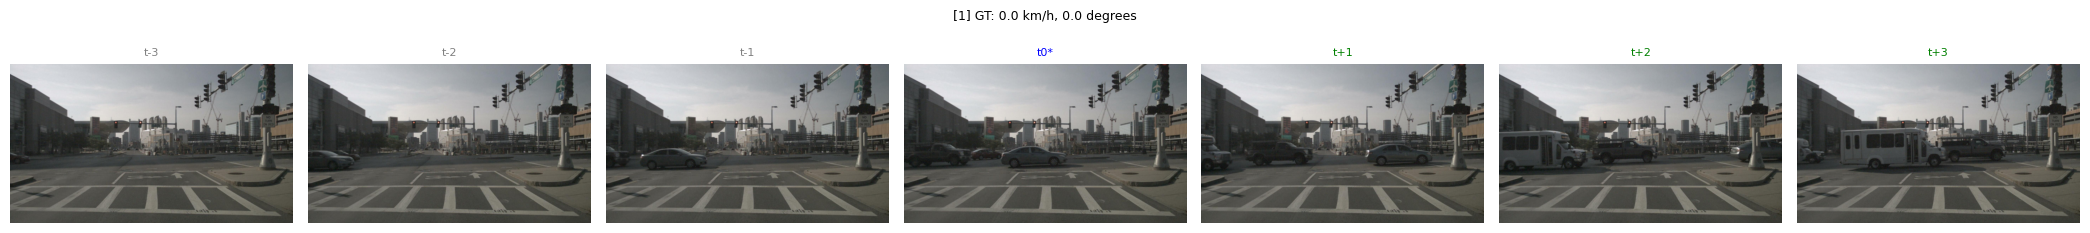


NON POST-HOC (4 images)...


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3: Smoke test -- SA pipeline on 2 samples
# Sample 0: stationary (GT speed=0, angle=0)
# Sample 7: moving     (GT speed=8.42 m/s, angle=-2.58 degrees)
# ─────────────────────────────────────────────────────────────────────────────

smoke_results = []

for SAMPLE_IDX in [0, 7]:
    s      = data[SAMPLE_IDX]
    fd     = s['frame_dir']
    gt     = get_gt_continuous(s)
    prev   = get_prev_continuous(s)
    n_past = s.get('n_past', 0)

    print(f"\n{'='*60}")
    print(f"Sample {SAMPLE_IDX+1}: {s['sample_token'][:12]}...")
    print(f"GT speed:    {gt.get('avg_speed_mps')} m/s ({gt.get('avg_speed_kph')} km/h)")
    print(f"GT angle:    {gt.get('angle_overall_deg')} degrees")
    print(f"GT accel:    {gt.get('acceleration_mps2')} m/s2")
    print(f"GT yaw rate: {gt.get('yaw_rate_deg_s')} deg/s")

    # Show all frames
    all_paths, all_labels = [], []
    for i in range(n_past, 0, -1):
        path = f"{fd}/tm{i}.jpg"
        if os.path.exists(path):
            all_paths.append(path)
            all_labels.append(f"t-{i}")
    all_paths.append(f"{fd}/t0.jpg")
    all_labels.append("t0*")
    for i in range(1, 4):
        all_paths.append(f"{fd}/t{i}.jpg")
        all_labels.append(f"t+{i}")

    fig, axes = plt.subplots(1, len(all_paths), figsize=(len(all_paths)*3, 2.5))
    for ax, path, label in zip(axes, all_paths, all_labels):
        ax.imshow(Image.open(path))
        ax.set_title(label, fontsize=8,
                     color='blue'  if '*' in label else
                           'green' if '+' in label else 'gray')
        ax.axis('off')
    plt.suptitle(
        f"[{SAMPLE_IDX+1}] GT: {gt.get('avg_speed_kph')} km/h, {gt.get('angle_overall_deg')} degrees",
        fontsize=9)
    plt.tight_layout()
    plt.show()

    # Run non post-hoc
    non_imgs = get_image_sequence(s, 'non_posthoc')
    print(f"\nNON POST-HOC ({len(non_imgs)} images)...")
    t0 = time.time()
    out_non = run_condition_v5(s, 'non_posthoc')
    elapsed = time.time() - t0
    print(f"Done in {elapsed:.1f}s")
    # NEW
    print(f"  Predicted: direction={out_non['direction']}, speed={out_non['speed']}")
    print(f"  GT:        direction={out_non['gt_direction']}, speed={out_non['gt_speed']}")
    print(f"  Match:     direction={'OK' if out_non['direction_correct'] else 'WRONG'}, "
          f"speed={'OK' if out_non['speed_correct'] else 'WRONG'}, "
          f"full={'OK' if out_non['full_correct'] else 'WRONG'}")

    # Run post-hoc
    post_imgs = get_image_sequence(s, 'posthoc')
    print(f"\nPOST-HOC ({len(post_imgs)} images)...")
    t0 = time.time()
    out_post = run_condition_v5(s, 'posthoc')
    elapsed = time.time() - t0
    print(f"Done in {elapsed:.1f}s")
    # NEW
    print(f"  Predicted: direction={out_non['direction']}, speed={out_non['speed']}")
    print(f"  GT:        direction={out_non['gt_direction']}, speed={out_non['gt_speed']}")
    print(f"  Match:     direction={'OK' if out_non['direction_correct'] else 'WRONG'}, "
          f"speed={'OK' if out_non['speed_correct'] else 'WRONG'}, "
          f"full={'OK' if out_non['full_correct'] else 'WRONG'}")
    # Save
    smoke_results.append({
        'sample_idx':      SAMPLE_IDX,
        'sample_token':    s['sample_token'],
        'gt_continuous':   gt,
        'prev_continuous': prev,
        'non_posthoc':     out_non,
        'posthoc':         out_post,
    })
    with open('results/smoke_test_v5_outputs.json', 'w') as f:
        json.dump(smoke_results, f, indent=2)
    print("Saved checkpoint.")

    # Debug display: SA chain of thought (collapsible per condition)
    for cond_label, out in [('NON POST-HOC', out_non), ('POST-HOC', out_post)]:
        # NEW table — replaces the entire display(HTML(...)) table block
        display(HTML(
            f'<table style="width:100%; border-collapse:collapse; font-size:12px; font-family:monospace;">'
            f'<tr style="background:#e8f0fe;">'
            f'<th style="padding:8px; border:1px solid #ccc;">Metric</th>'
            f'<th style="padding:8px; border:1px solid #ccc;">GT</th>'
            f'<th style="padding:8px; border:1px solid #ccc;">NON POST-HOC ({len(non_imgs)} imgs)</th>'
            f'<th style="padding:8px; border:1px solid #ccc;">Match</th>'
            f'<th style="padding:8px; border:1px solid #ccc;">POST-HOC ({len(post_imgs)} imgs)</th>'
            f'<th style="padding:8px; border:1px solid #ccc;">Match</th>'
            f'</tr>'
            f'<tr>'
            f'<td style="padding:8px; border:1px solid #ccc;">Direction</td>'
            f'<td style="padding:8px; border:1px solid #ccc;">{out_non["gt_direction"]}</td>'
            f'<td style="padding:8px; border:1px solid #ccc;">{out_non["direction"]}</td>'
            f'<td style="padding:8px; border:1px solid #ccc; color:{"green" if out_non["direction_correct"] else "red"};">'
            f'{"OK" if out_non["direction_correct"] else "WRONG"}</td>'
            f'<td style="padding:8px; border:1px solid #ccc;">{out_post["direction"]}</td>'
            f'<td style="padding:8px; border:1px solid #ccc; color:{"green" if out_post["direction_correct"] else "red"};">'
            f'{"OK" if out_post["direction_correct"] else "WRONG"}</td>'
            f'</tr>'
            f'<tr>'
            f'<td style="padding:8px; border:1px solid #ccc;">Speed</td>'
            f'<td style="padding:8px; border:1px solid #ccc;">{out_non["gt_speed"]}</td>'
            f'<td style="padding:8px; border:1px solid #ccc;">{out_non["speed"]}</td>'
            f'<td style="padding:8px; border:1px solid #ccc; color:{"green" if out_non["speed_correct"] else "red"};">'
            f'{"OK" if out_non["speed_correct"] else "WRONG"}</td>'
            f'<td style="padding:8px; border:1px solid #ccc;">{out_post["speed"]}</td>'
            f'<td style="padding:8px; border:1px solid #ccc; color:{"green" if out_post["speed_correct"] else "red"};">'
            f'{"OK" if out_post["speed_correct"] else "WRONG"}</td>'
            f'</tr>'
            f'<tr style="background:#f0f0f0;">'
            f'<td style="padding:8px; border:1px solid #ccc;">Full match</td>'
            f'<td style="padding:8px; border:1px solid #ccc;">both correct</td>'
            f'<td colspan="2" style="padding:8px; border:1px solid #ccc; '
            f'color:{"green" if out_non["full_correct"] else "red"}; font-weight:bold;">'
            f'{"OK" if out_non["full_correct"] else "WRONG"}</td>'
            f'<td colspan="2" style="padding:8px; border:1px solid #ccc; '
            f'color:{"green" if out_post["full_correct"] else "red"}; font-weight:bold;">'
            f'{"OK" if out_post["full_correct"] else "WRONG"}</td>'
            f'</tr>'
            f'<tr style="background:#f0f0f0;">'
            f'<td colspan="2" style="padding:8px; border:1px solid #ccc;">Reasoning</td>'
            f'<td colspan="2" style="padding:8px; border:1px solid #ccc;">{out_non["reasoning"][:200]}</td>'
            f'<td colspan="2" style="padding:8px; border:1px solid #ccc;">{out_post["reasoning"][:200]}</td>'
            f'</tr>'
            f'</table>'
        ))

print(f"\n{'='*60}")
print(f"Smoke test complete. {len(smoke_results)} samples saved.")
print("File: results/smoke_test_v5_outputs.json")


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4: Full inference -- all 24 samples with SA pipeline
# Checkpoints after every sample -- safe to interrupt and resume
# Output: results/inference_outputs_v5.json
# ─────────────────────────────────────────────────────────────────────────────

CHECKPOINT_FILE = 'results/inference_checkpoint_v5.json'
OUTPUT_FILE     = 'results/inference_outputs_v5.json'

done_tokens = set()
results = []
if os.path.exists(CHECKPOINT_FILE):
    with open(CHECKPOINT_FILE) as f:
        results = json.load(f)
    done_tokens = {r['sample_token'] for r in results}
    print(f"Resuming from checkpoint: {len(done_tokens)}/24 done")
else:
    print("Starting fresh run...")

total_start = time.time()

for idx, s in enumerate(data):
    if s['sample_token'] in done_tokens:
        print(f"[{idx+1}/24] Skipping {s['sample_token'][:8]}... (already done)")
        continue

    gt     = get_gt_continuous(s)
    prev   = get_prev_continuous(s)
    n_past = s.get('n_past', 0)
    fd     = s['frame_dir']

    print(f"\n[{idx+1}/24] {s['sample_token'][:8]}... "
          f"GT: {gt.get('avg_speed_kph')} km/h, {gt.get('angle_overall_deg')} degrees")

    # Show frames
    all_paths, all_labels = [], []
    for i in range(n_past, 0, -1):
        path = f"{fd}/tm{i}.jpg"
        if os.path.exists(path):
            all_paths.append(path)
            all_labels.append(f"t-{i}")
    all_paths.append(f"{fd}/t0.jpg")
    all_labels.append("t0*")
    for i in range(1, 4):
        all_paths.append(f"{fd}/t{i}.jpg")
        all_labels.append(f"t+{i}")

    fig, axes = plt.subplots(1, len(all_paths), figsize=(len(all_paths)*3, 2.5))
    for ax, path, label in zip(axes, all_paths, all_labels):
        ax.imshow(Image.open(path))
        ax.set_title(label, fontsize=8,
                     color='blue'  if '*' in label else
                           'green' if '+' in label else 'gray')
        ax.axis('off')
    plt.suptitle(f"[{idx+1}/24] GT: {gt.get('avg_speed_kph')} km/h {gt.get('angle_overall_deg')} degrees",
                 fontsize=9)
    plt.tight_layout()
    plt.show()

    # Non post-hoc
    n_non = len(get_image_sequence(s, 'non_posthoc'))
    print(f"  NON POST-HOC ({n_non} imgs)...", end=' ')
    t0 = time.time()
    out_non = run_condition_v5(s, 'non_posthoc')
    print(f"{time.time()-t0:.1f}s -> "
      f"dir={'OK' if out_non['direction_correct'] else 'WRONG'} ({out_non['direction']}), "
      f"spd={'OK' if out_non['speed_correct'] else 'WRONG'} ({out_non['speed']})")

    # Post-hoc
    n_post = len(get_image_sequence(s, 'posthoc'))
    print(f"  POST-HOC ({n_post} imgs)...", end=' ')
    t0 = time.time()
    out_post = run_condition_v5(s, 'posthoc')
    print(f"{time.time()-t0:.1f}s -> "
      f"dir={'OK' if out_non['direction_correct'] else 'WRONG'} ({out_non['direction']}), "
      f"spd={'OK' if out_non['speed_correct'] else 'WRONG'} ({out_non['speed']})")

    results.append({
        'sample_token':    s['sample_token'],
        'scene_token':     s['scene_token'],
        'gt_continuous':   gt,
        'prev_continuous': prev,
        'trajectory':      s['trajectory'],
        'past_trajectory': s.get('past_trajectory', []),
        'n_past':          n_past,
        'non_posthoc':     out_non,
        'posthoc':         out_post,
    })

    with open(CHECKPOINT_FILE, 'w') as f:
        json.dump(results, f, indent=2)

        # NEW
        display(HTML(
            f'<div style="font-family:monospace; font-size:12px; padding:8px; '
            f'border-left:4px solid #4C72B0; margin:4px 0; background:#f1f8e9;">'
            f'<b>[{idx+1}/24]</b> &nbsp;'
            f'GT: <b>{out_non["gt_direction"]} | {out_non["gt_speed"]}</b>'
            f' &nbsp;|&nbsp; '
            f'NON: {out_non["direction"]} | {out_non["speed"]} '
            f'[{"OK" if out_non["full_correct"] else "WRONG"}]'
            f' &nbsp;|&nbsp; '
            f'POST: {out_post["direction"]} | {out_post["speed"]} '
            f'[{"OK" if out_post["full_correct"] else "WRONG"}]'
            f'</div>'
        ))

with open(OUTPUT_FILE, 'w') as f:
    json.dump(results, f, indent=2)

total_time = time.time() - total_start
# NEW — replaces the entire MAE print block at the bottom of Cell 4
n = len(results)

dir_acc_non  = sum(r['non_posthoc']['direction_correct'] for r in results) / n
dir_acc_post = sum(r['posthoc']['direction_correct']     for r in results) / n
spd_acc_non  = sum(r['non_posthoc']['speed_correct']     for r in results) / n
spd_acc_post = sum(r['posthoc']['speed_correct']         for r in results) / n
full_acc_non  = sum(r['non_posthoc']['full_correct']     for r in results) / n
full_acc_post = sum(r['posthoc']['full_correct']         for r in results) / n

print(f"\n{'='*55}")
print(f"DONE -- {n} samples in {total_time/60:.1f} minutes")
print(f"\n{'Metric':<20} {'NON POST-HOC':>14} {'POST-HOC':>14} {'Delta':>10}")
print("-"*55)
print(f"{'Direction acc':<20} {dir_acc_non:>14.3f} {dir_acc_post:>14.3f} "
      f"{dir_acc_post - dir_acc_non:>+10.3f}")
print(f"{'Speed acc':<20} {spd_acc_non:>14.3f} {spd_acc_post:>14.3f} "
      f"{spd_acc_post - spd_acc_non:>+10.3f}")
print(f"{'Full match acc':<20} {full_acc_non:>14.3f} {full_acc_post:>14.3f} "
      f"{full_acc_post - full_acc_non:>+10.3f}")
print(f"\nSaved to: {OUTPUT_FILE}")
